# $Digit-Recognition-Project$

In [7]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# CNN
import tensorflow as tf
from keras.datasets import mnist


## Loaded a dataset

In [27]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

## Data Transfomations
- you altering/engineering the data
- Feature engineering in ML
- Change features in a way, that help the model learn better
- what we are dealing with right now are images:
    

In [15]:
np.set_printoptions(linewidth= 150)
print(X_train[0][6:20, 6:20])
print("Label : ", y_train[0])

[[  0   0  30  36  94 154 170 253 253 253 253 253 225 172]
 [  0  49 238 253 253 253 253 253 253 253 253 251  93  82]
 [  0  18 219 253 253 253 253 253 198 182 247 241   0   0]
 [  0   0  80 156 107 253 253 205  11   0  43 154   0   0]
 [  0   0   0  14   1 154 253  90   0   0   0   0   0   0]
 [  0   0   0   0   0 139 253 190   2   0   0   0   0   0]
 [  0   0   0   0   0  11 190 253  70   0   0   0   0   0]
 [  0   0   0   0   0   0  35 241 225 160 108   1   0   0]
 [  0   0   0   0   0   0   0  81 240 253 253 119  25   0]
 [  0   0   0   0   0   0   0   0  45 186 253 253 150  27]
 [  0   0   0   0   0   0   0   0   0  16  93 252 253 187]
 [  0   0   0   0   0   0   0   0   0   0   0 249 253 249]
 [  0   0   0   0   0   0   0   0  46 130 183 253 253 207]
 [  0   0   0   0   0   0  39 148 229 253 253 253 250 182]]
Label :  5


In [28]:
# scaling operation
#X_train = X_train/255.0
#X_test = X_test/255.0

X_train =  X_train.reshape(60000, 28, 28, 1)
X_test = X_test = X_test.reshape(10000, 28, 28, 1)

## Load a model, and train some more

In [49]:
# load the model
old_model = tf.keras.models.load_model('my_cnn.keras')
model = tf.keras.models.load_model('my_cnn.keras')

In [21]:
# model.summary()

In [50]:
history = model.fit(X_train, y_train, 
                    batch_size = 64, 
                    epochs = 10, 
                    validation_split = 0.2, 
                    verbose = 1)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.9806 - loss: 0.0598 - val_accuracy: 0.9868 - val_loss: 0.0470
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.9811 - loss: 0.0592 - val_accuracy: 0.9890 - val_loss: 0.0387
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.9834 - loss: 0.0533 - val_accuracy: 0.9887 - val_loss: 0.0395
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9837 - loss: 0.0534 - val_accuracy: 0.9898 - val_loss: 0.0357
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.9850 - loss: 0.0479 - val_accuracy: 0.9886 - val_loss: 0.0413
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.9861 - loss: 0.0432 - val_accuracy: 0.9887 - val_loss: 0.0394
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.9871 - loss: 0.0422 - val_accuracy: 0.9891 - val_loss: 0.0412
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.9880 - loss: 0.0385 - 

- Performance over the Epochs

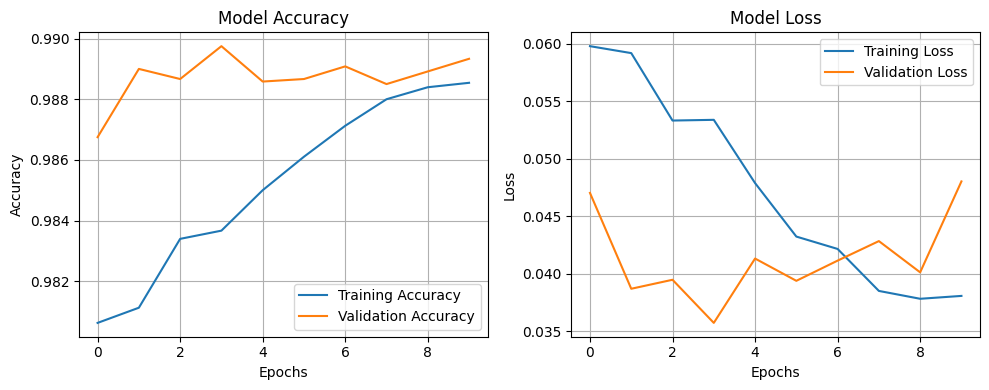

In [51]:
history = pd.DataFrame(history.history)
history # accuracy	loss	val_accuracy	val_loss

# Plot Accuracy
plt.figure(figsize=(10, 4))

plt.subplot(1,2,1)
plt.plot(history.accuracy, label = "Training Accuracy")
plt.plot(history.val_accuracy, label = "Validation Accuracy")
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.grid()
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.loss, label = "Training Loss" )
plt.plot(history.val_loss, label = "Validation Loss" )
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

## Let's evaluate the model

In [55]:
# evaluate
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print(f'Accuracy = {test_accuracy*100:.2f}%')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9885 - loss: 0.0364
Accuracy = 98.85%


- Accuracy = 11.35%
    - Becuase our model was trained on raw pixel values first
    - we loaded the model and fed it scaled data ---> by dividing with 255.0 and that broke the model down
    - 
- Learning rate shock
    - The new weight updates were too massive
1. We did Data Augmentation - adding more data to training
    - the augmented data, should be of the same scale as the data model was trained on initially 
2. Large weight updates made the model forget all that it had learned

## Make predictions
- on an dataset or
- on an external image

In [53]:
X_test[4].reshape(1,28,28,1).shape


(1, 28, 28, 1)

In [56]:
# using the RETRAINED MODEL ----> model
test_img = X_test[2].reshape(1,28,28,1)
prediction = model.predict(test_img)
pred_digit = np.argmax(prediction)


print(f'image label: {y_test[4]} | Prediction : {pred_digit}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
image label: 4 | Prediction : 1


In [57]:
# using the OLD MODEL ----> model
test_img = X_test[2].reshape(1,28,28,1)
prediction = old_model.predict(test_img)
pred_digit = np.argmax(prediction)


print(f'image label: {y_test[4]} | Prediction : {pred_digit}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
image label: 4 | Prediction : 1


- We can think about improving model performance later

In [ ]:
# load an image
from PIL import Image, ImageOps

img = Image.open("five_img.jpg")
img = Image.open("three_img.jpg")
#img # will be shown as it is

img = ImageOps.invert(img) # Invert the colors

# shape --> (398, 513, 3)
img = img.resize(size=(28,28)) # resize to the size compatible with the shape our model will use later
# shape --> (28,28, 3)

img = img.convert('L') # Greyscale ---> L is lumincance
# shape --> (28,28)

img_array = np.array(img) # PIL.JpegImagePlugin.JpegImageFile

img_array_reshaped = img_array.reshape(1,28,28,1)

# using the model for predictions
test_img = img_array_reshaped
prediction = old_model.predict(test_img)
pred_digit = np.argmax(prediction)

print(f'The Model Prediction is : {pred_digit}')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
The Model Prediction is : 3
